In [1]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls

Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 615, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 615 (delta 13), reused 20 (delta 10), pack-reused 586 (from 1)
Receiving objects: 100% (615/615), 764.37 KiB | 2.56 MiB/s, done.
Resolving deltas: 100% (291/291), done.
/content/NuOscProbExact/src
globaldefs.py  hamiltonians2nu.py  hamiltonians3nu.py  oscprob2nu.py  oscprob3nu.py


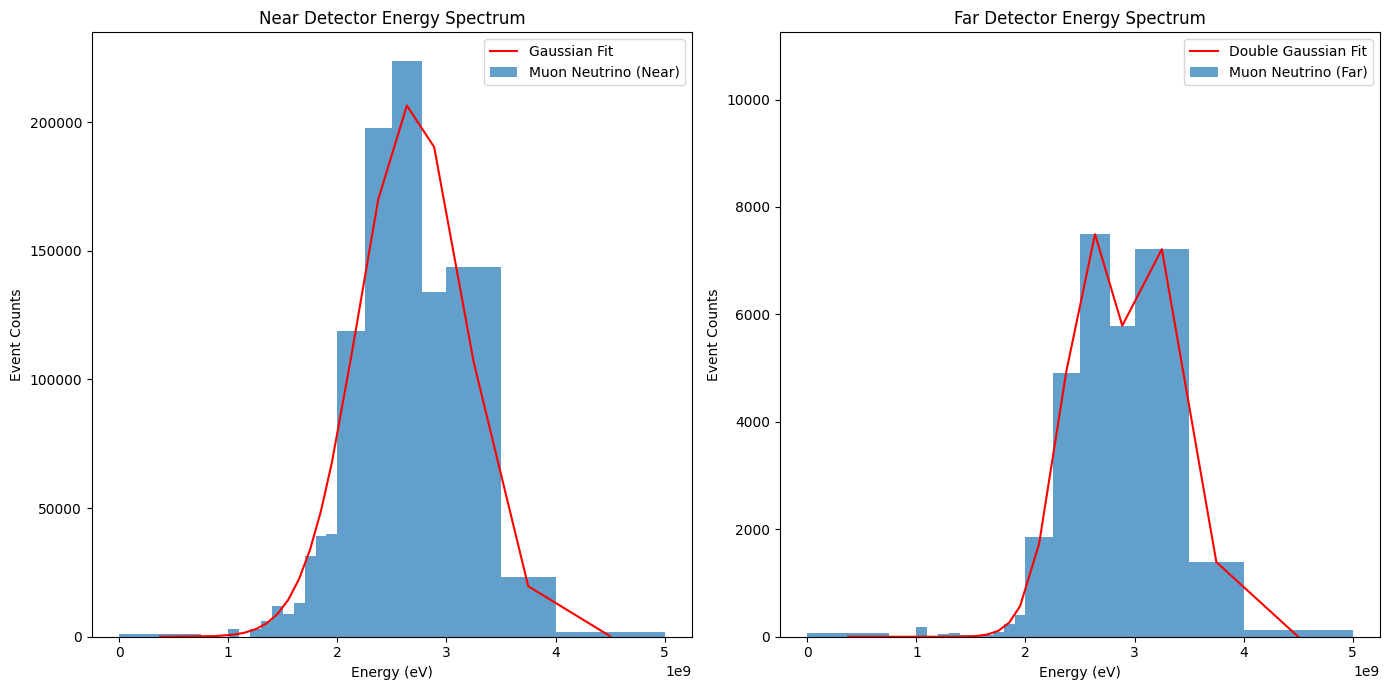

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from NuOscProbExact.src.oscprob3nu import probabilities_3nu
from NuOscProbExact.src.hamiltonians3nu import hamiltonian_3nu_vacuum_energy_independent, hamiltonian_3nu_matter
from NuOscProbExact.src.globaldefs import *

# Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Define a Gaussian energy distribution
mean_energy = 2.5e9  # Mean energy in eV (corresponds to 2.5 GeV)
sigma_energy = 0.5e9  # Standard deviation in eV
energies = np.random.normal(mean_energy, sigma_energy, 1000)

# Initialize the vacuum Hamiltonian (energy-independent part)
h_vacuum_energy_indep = hamiltonian_3nu_vacuum_energy_independent(
    S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
)

# Function to compute probabilities with matter effects for a given baseline
def compute_probabilities_matter(baseline):
    Prob_e = []
    Prob_mu = []
    Prob_tau = []

    for E in energies:
        # Define matter Hamiltonian for each energy
        h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)

        # Calculate probabilities for this Hamiltonian and baseline
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
        Prob_e.append(Pee)
        Prob_mu.append(Pmm)
        Prob_tau.append(Ptt)

    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau)

# Compute probabilities for near and far detectors
Prob_e_near, Prob_mu_near, Prob_tau_near = compute_probabilities_matter(Length_near)
Prob_e_far, Prob_mu_far, Prob_tau_far = compute_probabilities_matter(Length_far)

# Total number of events for near and far detectors
total_events_near = 1000
total_events_far = 100

# Generate Poisson-distributed event counts based on the probabilities
counts_mu_near = np.random.poisson(lam=Prob_mu_near * total_events_near)
counts_mu_far = np.random.poisson(lam=Prob_mu_far * total_events_far)

# Define bin edges and centers for plotting
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9  # in eV
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# Compute histograms for near and far detectors using the predefined bin edges
hist_near, _ = np.histogram(energies, bins=bin_edges, weights=counts_mu_near)
hist_far, _ = np.histogram(energies, bins=bin_edges, weights=counts_mu_far)

# Gaussian fitting functions
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def double_gaussian(x, A1, mu1, sigma1, A2, mu2, sigma2):
    return gaussian(x, A1, mu1, sigma1) + gaussian(x, A2, mu2, sigma2)

# Fit near detector histogram with a single Gaussian
popt_near, _ = curve_fit(gaussian, bin_centers, hist_near, p0=[np.max(hist_near), mean_energy, sigma_energy])

# Fit far detector histogram with a double Gaussian
popt_far, _ = curve_fit(double_gaussian, bin_centers, hist_far,
                        p0=[np.max(hist_far) / 2, mean_energy * 0.9, sigma_energy,
                            np.max(hist_far) / 2, mean_energy * 1.1, sigma_energy])

# Plot the histograms and the Gaussian fits
plt.figure(figsize=(14, 7))

# Near detector
plt.subplot(1, 2, 1)
plt.bar(bin_centers, hist_near, width=np.diff(bin_edges), align='center', alpha=0.7, label='Muon Neutrino (Near)')
plt.plot(bin_centers, gaussian(bin_centers, *popt_near), 'r-', label='Gaussian Fit')
plt.xlabel('Energy (eV)')
plt.ylabel('Event Counts')
plt.title('Near Detector Energy Spectrum')
plt.legend()

# Far detector
plt.subplot(1, 2, 2)
plt.bar(bin_centers, hist_far, width=np.diff(bin_edges), align='center', alpha=0.7, label='Muon Neutrino (Far)')
plt.plot(bin_centers, double_gaussian(bin_centers, *popt_far), 'r-', label='Double Gaussian Fit')
plt.xlabel('Energy (eV)')
plt.ylabel('Event Counts')
plt.title('Far Detector Energy Spectrum')
plt.legend()
plt.ylim(0, np.max(hist_far) * 1.5)

plt.tight_layout()
plt.show()
